In [1]:
# %%
import jax, jax.numpy as jnp
from tests.utils import Generator
from slimdqn.algorithms.dqn import DQN
from slimdqn.algorithms.dqnrcshared import DQNRCShared
from slimdqn.algorithms.idqnshared import iDQNShared
from slimdqn.algorithms.gidqnshared import GiDQNShared

KEY             = jax.random.PRNGKey(0)
N_ACTIONS       = 10
N_BELLMAN_ITERS = 5
LR, GAMMA       = 6.25e-5, 0.99

ARCHITECTURES = {
    "large": dict(features=[32, 64, 64, 512], observation_dim=(84, 84, 4), batch_size=32),  # Dopamine / Nature-CNN
    "small": dict(features=[16, 256],         observation_dim=(16, 16, 2), batch_size=16),  # downscaled
}
ALGO_ORDER = ["dqn", "qrc", "idqn", "gidqn"]

count_params = lambda t: sum(x.size   for x in jax.tree.leaves(t))
tree_bytes   = lambda t: sum(x.nbytes for x in jax.tree.leaves(t))


def build_algos(features, obs):
    return {
        "dqn":   (DQN(KEY, obs, N_ACTIONS, features, LR, GAMMA, 1, 1, 8000), True),
        "qrc":   (DQNRCShared(KEY, obs, N_ACTIONS, features, LR, GAMMA, 1, 0.25, 8000, 1), False),
        "idqn":  (iDQNShared(KEY, obs, N_ACTIONS, N_BELLMAN_ITERS, features, LR, GAMMA, 1, 0.25, 8000), True),
        "gidqn": (GiDQNShared(KEY, obs, N_ACTIONS, N_BELLMAN_ITERS, features, LR, GAMMA, 1, 0.25, 8000, 1), True),
    }

def measure(q, has_target, gen, batch_size):
    key = jax.random.PRNGKey(0)
    if has_target:
        learn = jax.jit(q.learn_on_batch).lower(
            q.params, q.target_params, q.optimizer_state, gen.samples(key), jnp.ones(batch_size)
        ).compile()
    else:
        learn = jax.jit(q.learn_on_batch).lower(
            q.params, q.optimizer_state, gen.samples(key), jnp.ones(batch_size)
        ).compile()

    return {
        "flops":        learn.cost_analysis()[0]["flops"],
        "num_params":   count_params(q.params) + (count_params(q.target_params) if has_target else 0),
        "memory_bytes": tree_bytes(q.params) + tree_bytes(q.optimizer_state)
                        + (tree_bytes(q.target_params) if has_target else 0),
    }


results = {}
for arch, cfg in ARCHITECTURES.items():
    gen = Generator(cfg["batch_size"], cfg["observation_dim"], N_ACTIONS)
    results[arch] = {
        name: measure(q, has_t, gen, cfg["batch_size"])
        for name, (q, has_t) in build_algos(cfg["features"], cfg["observation_dim"]).items()
    }

print(results)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


{'large': {'dqn': {'flops': 329683456.0, 'num_params': 7314388, 'memory_bytes': 58515108}, 'qrc': {'flops': 482552800.0, 'num_params': 3662324, 'memory_bytes': 43947892}, 'idqn': {'flops': 399340864.0, 'num_params': 7334908, 'memory_bytes': 58761348}, 'gidqn': {'flops': 557066304.0, 'num_params': 7355428, 'memory_bytes': 59007588}}, 'small': {'dqn': {'flops': 39121120.0, 'num_params': 531316, 'memory_bytes': 4250532}, 'qrc': {'flops': 57957256.0, 'num_params': 268228, 'memory_bytes': 3218740}, 'idqn': {'flops': 49342352.0, 'num_params': 541596, 'memory_bytes': 4373892}, 'gidqn': {'flops': 69459840.0, 'num_params': 551876, 'memory_bytes': 4497252}}}


In [2]:
AVAILABLE_COLORS = {
    "black": "#000000",
    "blue": "#1F77B4",
    "light_blue": "#AEC7E8",
    "orange": "#FF7F0E",
    "light_orange": "#FFBB78",
    "green": "#2CA02C",
    "light_green": "#98DF8A",
    "red": "#D1797A",
    "light_red": "#FF9896",
    "purple": "#9467BD",
    "light_purple": "#C5B0D5",
    "brown": "#8C564B",
    "light_brown": "#C49C94",
    "pink": "#E377C2",
    "light_pink": "#F7B6D2",
    "grey": "#7F7F7F",
    "light_grey": "#C7C7C7",
    "yellow": "#DEDE00",
    "light_yellow": "#F0E886",
    "cyan": "#17BECF",
    "light_cyan": "#9EDAE5",
}


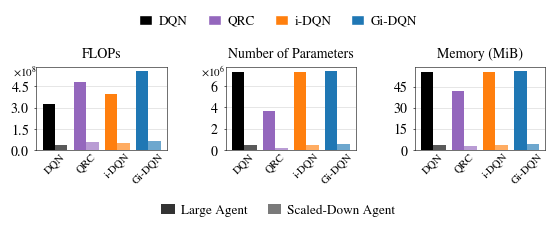

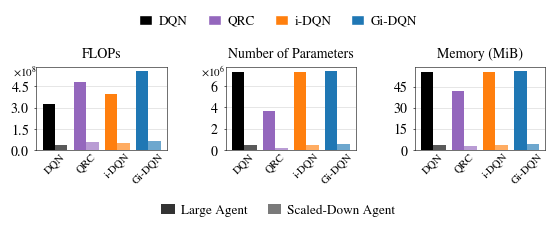

In [4]:
# %%
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from matplotlib.ticker import MaxNLocator

plt.rc("font", family="STIXGeneral", serif="Times New Roman", size=10)
plt.rc("mathtext", fontset="stix")
plt.rcParams.update({
    "axes.linewidth": 0.4, "lines.linewidth": 1.5,
    "xtick.major.width": 0, "ytick.major.width": 0.45,
    "xtick.major.size": 0, "ytick.major.size": 1.8, "grid.linewidth": 0.45,
})


ALGOS = {"dqn": "DQN", "qrc": "QRC", "idqn": "i-DQN", "gidqn": "Gi-DQN"}
ARCHS    = ["large", "small"]
METRICS  = [
    ("flops",        "FLOPs"),
    ("num_params",   "Number of Parameters"),
    ("memory_bytes", "Memory (MiB)"),
]
color = lambda a: {"dqn": "black", "qrc": "purple", "idqn": "orange", "gidqn": "blue"}[a]
light = lambda c: tuple(1 - (1 - x) * (1 - 0.35) for x in mcolors.to_rgb(c))

fig = plt.figure(figsize=(5.5, 2.15))
gs = fig.add_gridspec(1, 3, wspace=0.45)
x = np.arange(len(ALGOS))

for i, (key, title) in enumerate(METRICS):
    ax = fig.add_subplot(gs[i])
    vmax = max(results[ar][al][key] for ar in ARCHS for al in ALGOS.keys()) if not key=="memory_bytes" else max(results[ar][al][key]/ 1024**2 for ar in ARCHS for al in ALGOS.keys())
    for k, arch in enumerate(ARCHS):
        for j, algo in enumerate(ALGOS):
            c = AVAILABLE_COLORS[color(algo)]
            res = results[arch][algo][key] if not key == "memory_bytes" else results[arch][algo][key] / 1024**2
            ax.bar(x[j] + (k - 0.5) *  0.40, res, width= 0.40,
                   color=(c if arch == "large" else light(c)), zorder=3)
    ax.grid(axis="y", zorder=0)
    ax.set_xticks(x)
    ax.set_xticklabels([a for a in ALGOS.values()], rotation=45, ha="center", fontsize=8)
    ax.tick_params(axis="x", pad=1)
    ax.set_xlim(-0.6, len(ALGOS) - 0.4); ax.set_ylim(0, vmax * 1.06)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4))
    ax.set_title(title, fontsize=10, pad=6)
    if key != "memory_bytes":
        ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0), useMathText=True)
        #ax.yaxis.get_offset_text().set_fontsize(8)
        ax.yaxis.get_offset_text().set_visible(False)

algo_leg = [Patch(edgecolor="white", facecolor=AVAILABLE_COLORS[color(a)]) for a in ALGOS]
fig.legend(algo_leg, [a for a in ALGOS.values()], ncols=4, frameon=False, loc="center",
           bbox_to_anchor=(0.5, 0.94), columnspacing=1.5, handlelength=1,
           handletextpad=0.5, labelspacing=0.2, fontsize=9.5)

arch_leg = [Patch(facecolor="0.2"), Patch(facecolor=light("0.2"))]
fig.legend(arch_leg, ["Large Agent", "Scaled-Down Agent"], ncols=2, frameon=False, loc="center",
           bbox_to_anchor=(0.5, 0.06), columnspacing=1.5, handlelength=1,
           handletextpad=0.5, fontsize=9.5)

fig.subplots_adjust(left=0.06, right=0.985, bottom=0.34, top=0.73)
fig.savefig("footprint_grouped.pdf", pad_inches=0)

# place the x10^something somewhere else
fig.canvas.draw()
for ax in fig.axes:
    offset_text = ax.yaxis.get_offset_text()
    if offset_text.get_text():
        sci_text = offset_text.get_text()

        ax.text(0.0, 0.85, sci_text, transform=ax.transAxes,
                ha='right', va='bottom', fontsize=8)

fig